In [1]:
import os

from getdist import plots, loadMCSamples
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use(
    "/home/guerrini/matplotlib_config/paper.mplstyle"
)

sns.set_palette("husl")

g = plots.get_subplot_plotter(width_inch=30)
g.settings.axes_fontsize=60
g.settings.axes_labelsize=60
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 60

%matplotlib inline

#SPECIFY DATA DIRECTORY AND DESIRED CHAINS TO ANALYSE
root_dir = "/n09data/guerrini/output_chains/"

roots = [
    "SP_v1.4.6_leak_corr_A_lmin=300_lmax=1600_cell",
    "SP_v1.4.6_leak_corr_A_halofit_cell",
    "SP_v1.4.6_leak_corr_A_HMCode_nobar_cell",
]

print(roots)

os.makedirs("plots", exist_ok=True)
os.makedirs("plots/cosmological_constraints_NL_modelling", exist_ok=True)

['SP_v1.4.6_leak_corr_A_lmin=300_lmax=1600_cell', 'SP_v1.4.6_leak_corr_A_halofit_cell', 'SP_v1.4.6_leak_corr_A_HMCode_nobar_cell']


In [2]:
# MAKE PARAMNAMES FILE

for root in roots:
    with open(root_dir + '{}/samples_{}.txt'.format('/'+root ,root), "r") as file:
        params = file.readline()[1:].split('\t')[:-4]
        file.close()
 
    with open(root_dir + '{}/getdist_{}.paramnames'.format('/'+root, root), "w") as file:
        for i in range(len(params)):
            if len(params[i].split('--')) > 1:
                file.write(params[i].split('--')[1] + '\n')
            else:
                file.write(params[i].split('--')[0] + '\n')
        file.close()

In [3]:
#READ CHAIN

chains=[]

for root in roots:

    samples = np.loadtxt(root_dir + '{}/samples_{}.txt'.format(root,root))
    print(len(samples))
    if 'nautilus' in root:
        samples = np.column_stack((np.exp(samples[:,-3]),samples[:,-1]-samples[:,-2],samples[:,0:-3]))
    else:
        samples = np.column_stack((samples[:,-1],samples[:,-3],samples[:,0:-4]))
    np.savetxt(root_dir + '{}/getdist_{}.txt'.format(root,root), samples)
    
    chain = g.samples_for_root(root_dir + '{}/getdist_{}'.format(root,root),
                               cache=False,
                               settings={'ignore_rows':0,
                                         'smooth_scale_2D':0.5,
                                         'smooth_scale_1D':0.5})

    chains.append(chain)

1420
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_lmin=300_lmax=1600_cell/getdist_SP_v1.4.6_leak_corr_A_lmin=300_lmax=1600_cell.txt
Removed no burn in
1511
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_halofit_cell/getdist_SP_v1.4.6_leak_corr_A_halofit_cell.txt
Removed no burn in
1464
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_HMCode_nobar_cell/getdist_SP_v1.4.6_leak_corr_A_HMCode_nobar_cell.txt
Removed no burn in


In [4]:
name_list = ['OMEGA_M','ombh2','h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1']
label_list = ['\Omega_m', '\omega_b h^2', 'h_0', 'n_s', '\sigma_8', 'S_8', 'log T_{AGN}', 'A_{IA}', 'm_1', '\Delta z_1']

for chain in chains:
    param_names = chain.getParamNames()
    for name, label in zip(name_list, label_list):
        param_names.parWithName(name).label = label

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/getdist/plots.py:3347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.savefig(fname, bbox_extra_artists=self.extra_artists, bbox_inches='tight', **kwargs)
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


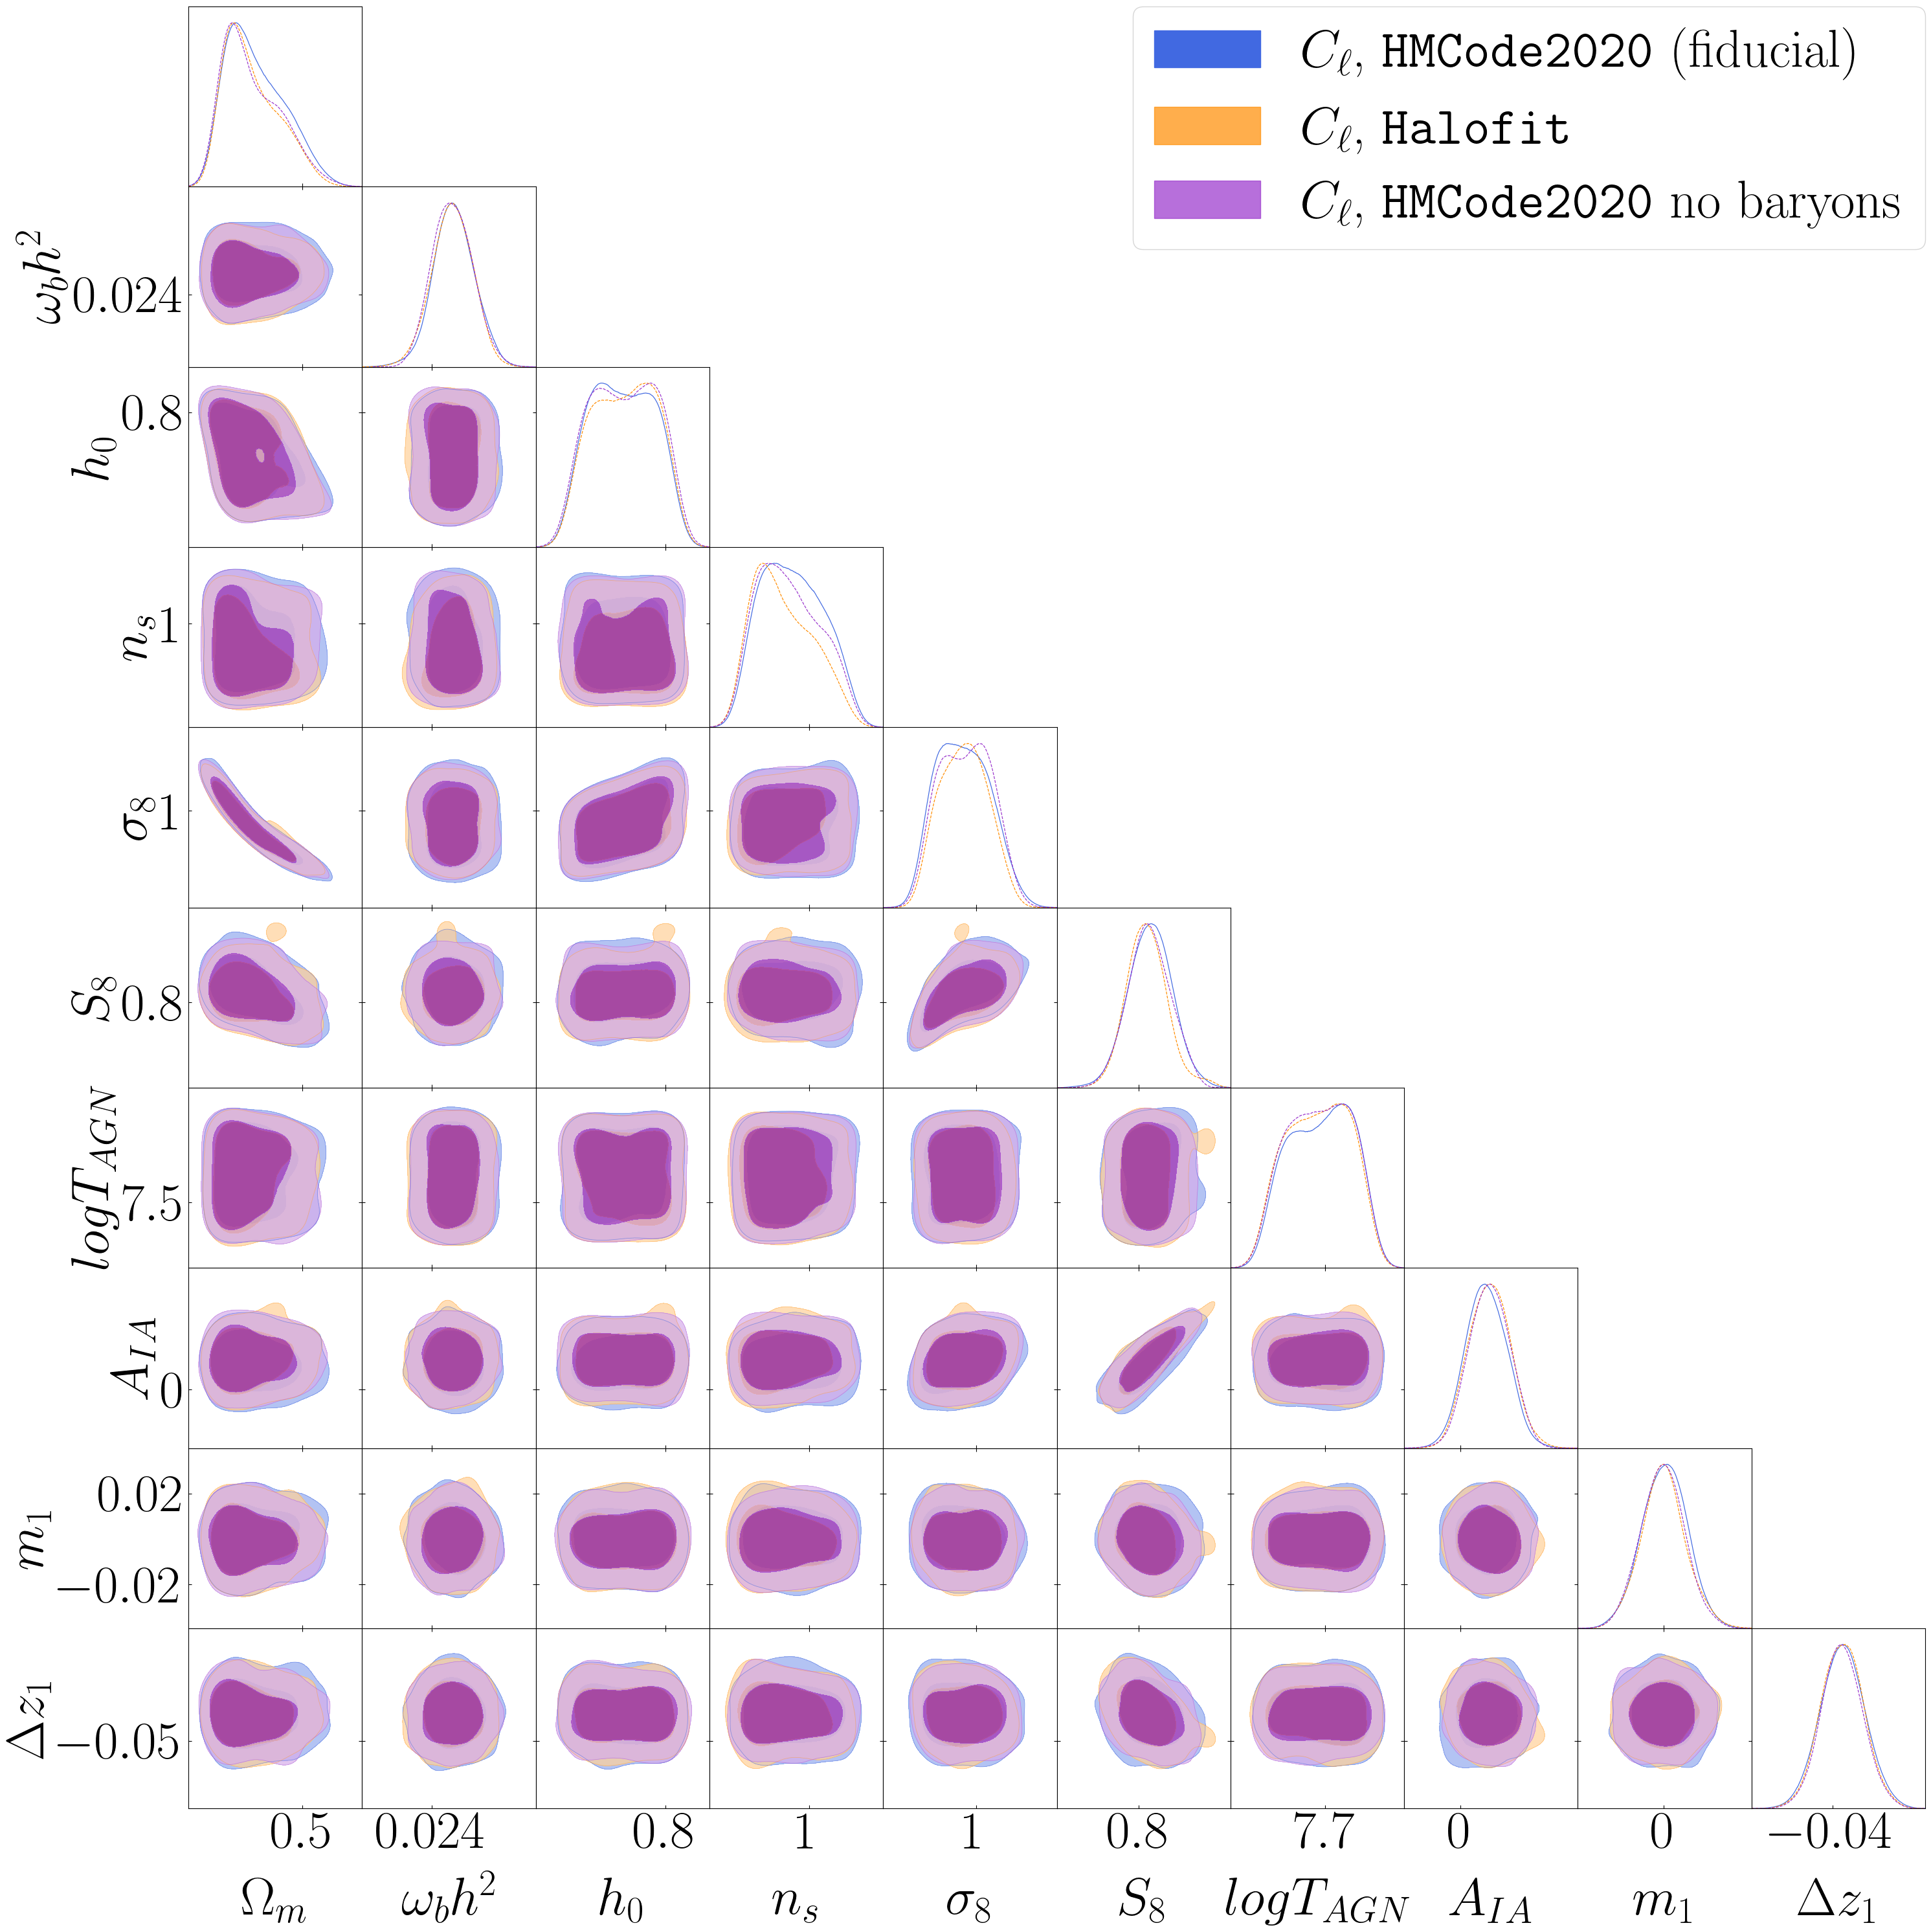

In [5]:
legend_labels = [
    r"$C_\ell$, \texttt{HMCode2020} (fiducial)",
    r"$C_\ell$, \texttt{Halofit}",
    r"$C_\ell$, \texttt{HMCode2020} no baryons",
]

colours = [
    "royalblue",
    "darkorange",
    "darkorchid"
]

linestyle = [
    'solid',
    'dashed',
    'dashed'
]

line_args = [dict(color=col, ls=ls) for col, ls in zip(colours, linestyle)]

#Plot all parameters
g.triangle_plot(
    chains,
    ['OMEGA_M','ombh2', 'h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1'],
    legend_labels=legend_labels,
    line_args=line_args,
    contour_colors=colours,
    legend_loc='upper right',

    filled=True
)

g.export('plots/cosmological_constraints_NL_modelling/contours_all_cell.png')
plt.show()

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/getdist/plots.py:3347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.savefig(fname, bbox_extra_artists=self.extra_artists, bbox_inches='tight', **kwargs)


/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


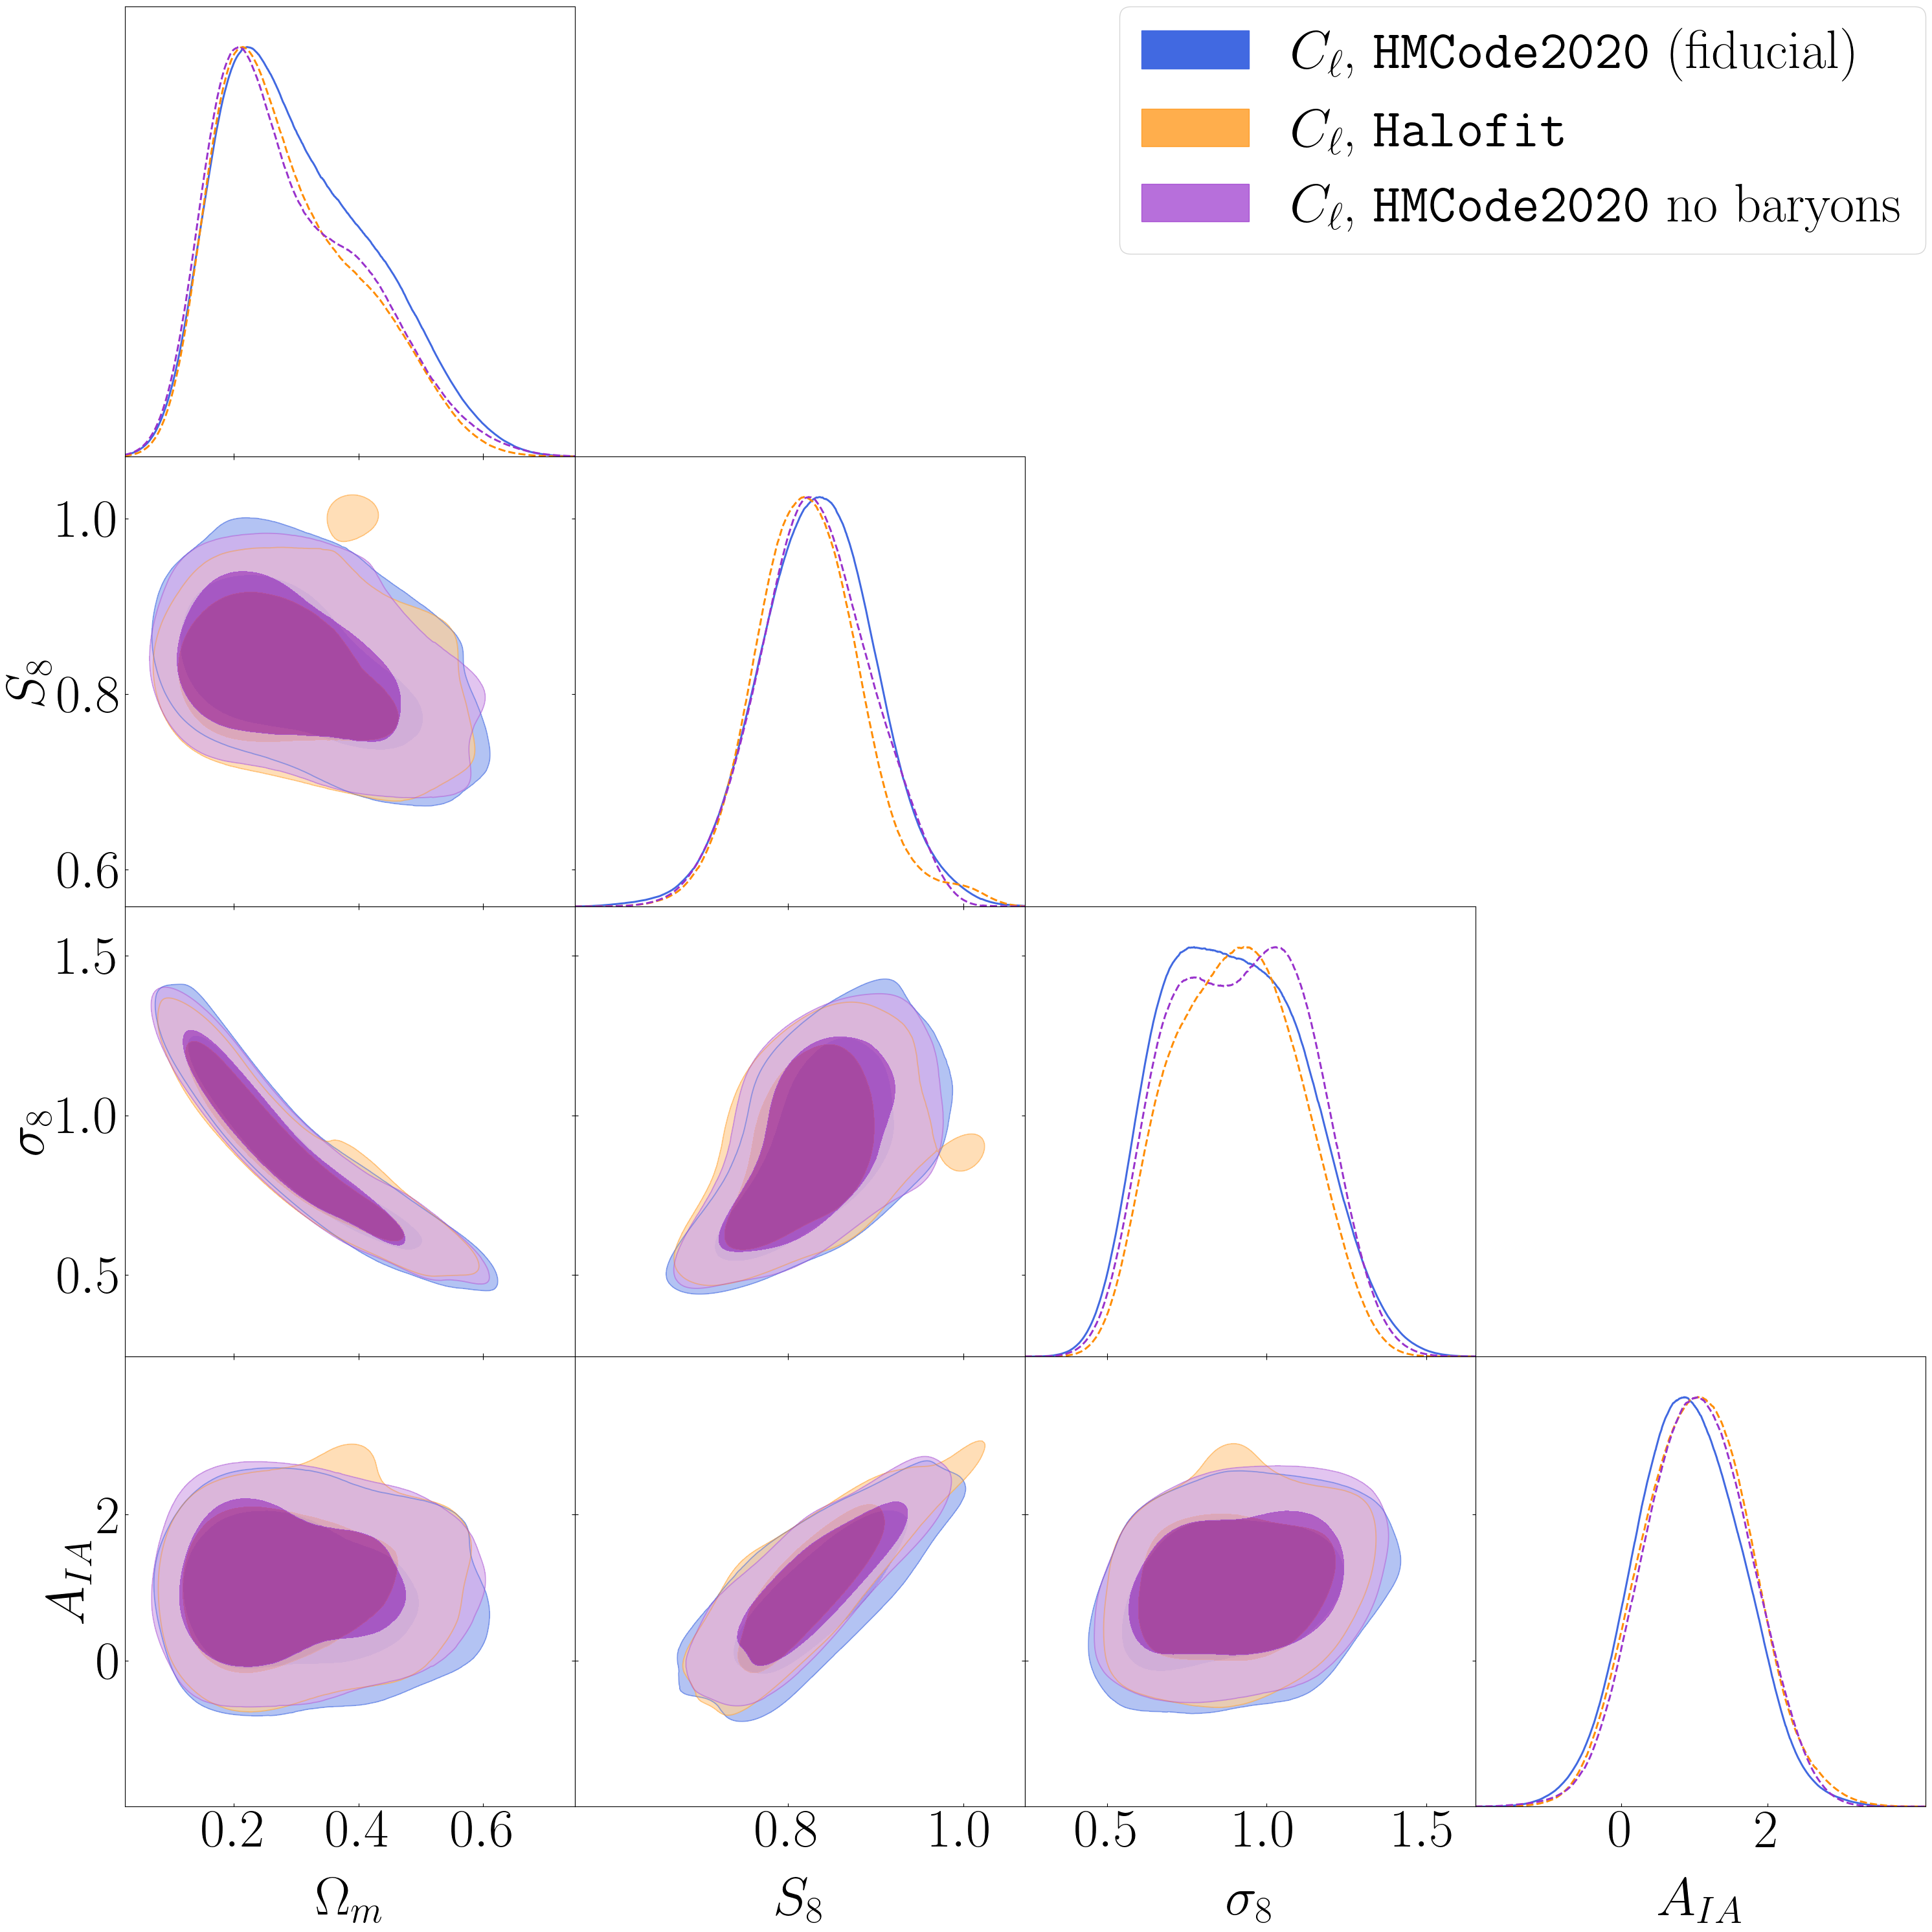

In [6]:
#Plot only cosmological parameters

g.triangle_plot(
    chains,
    ['OMEGA_M','s_8_input', 'SIGMA_8', 'a'],
    legend_labels=legend_labels,
    line_args=line_args,
    contour_colors=colours,
    legend_loc='upper right',
    filled=True
)

g.export('plots/cosmological_constraints_NL_modelling/contours_cosmo_cell.png')
plt.show()

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/getdist/plots.py:3347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.savefig(fname, bbox_extra_artists=self.extra_artists, bbox_inches='tight', **kwargs)


/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


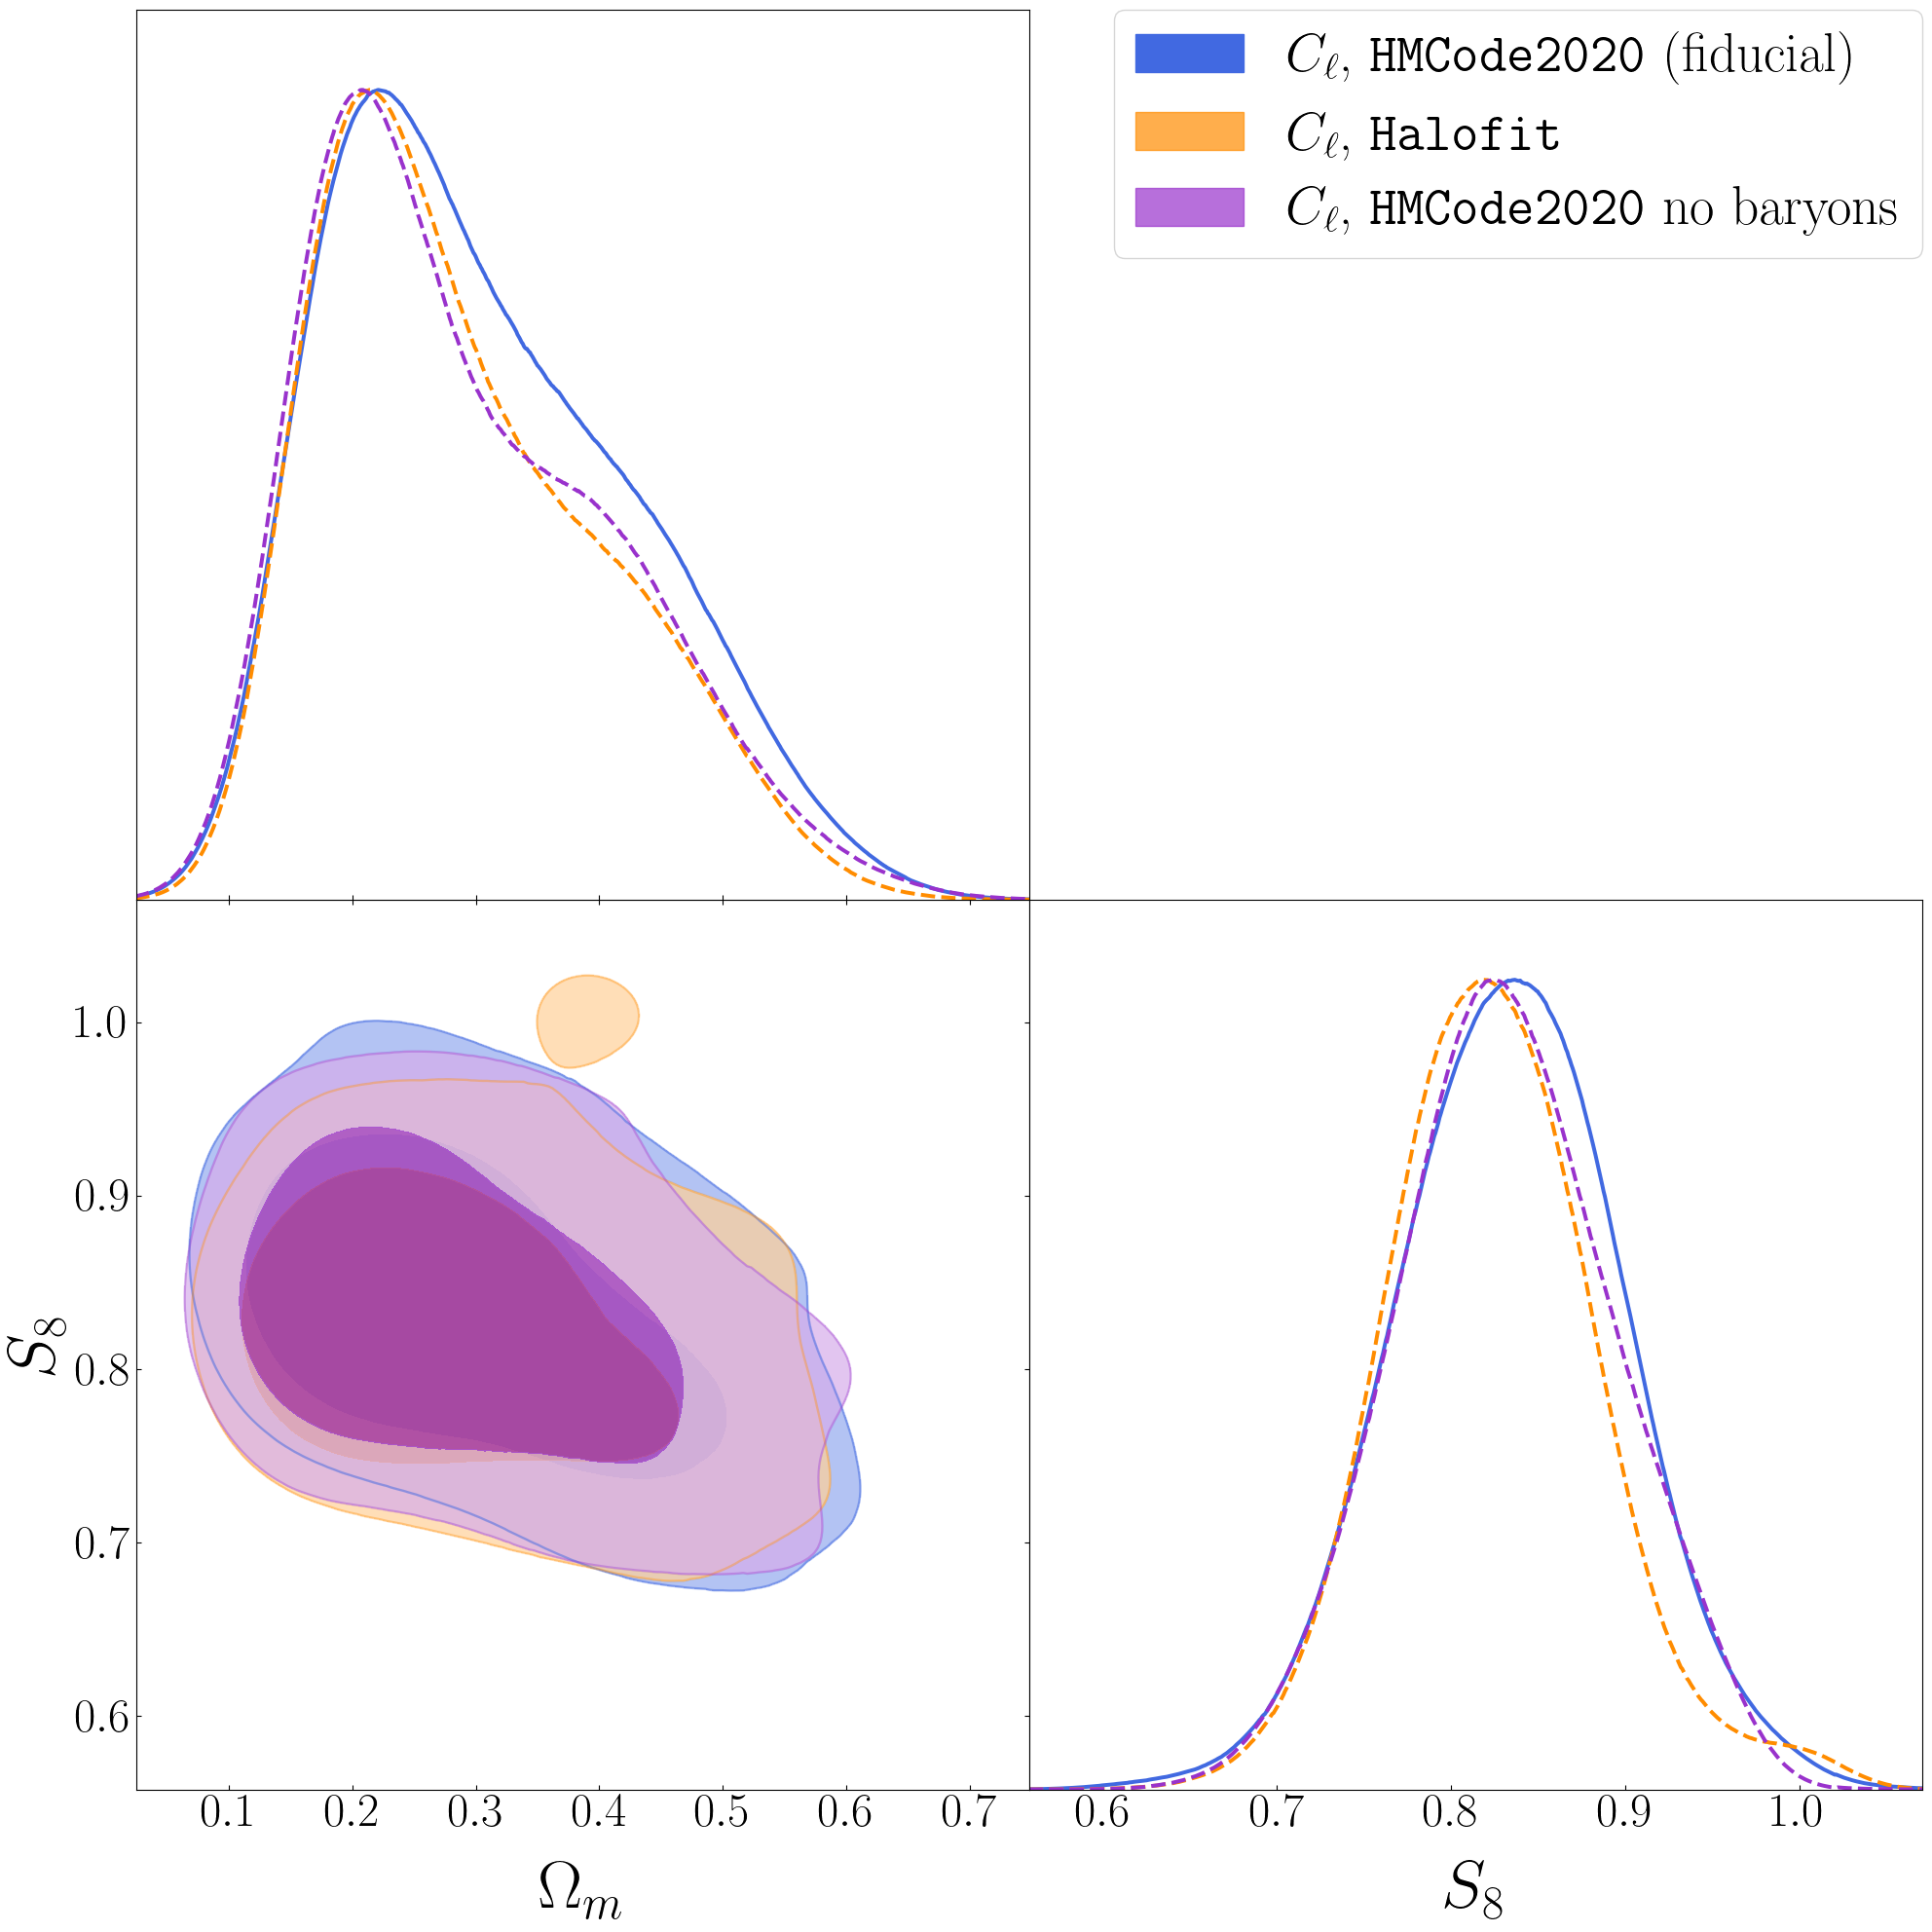

In [7]:
#Plot S8 Omega_m only
#Plot S8 Omega_m only
g = plots.get_subplot_plotter(width_inch=20)
g.settings.axes_fontsize=35
g.settings.axes_labelsize=50
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 40

g.triangle_plot(
    chains,
    ['OMEGA_M','s_8_input'],
    legend_labels=legend_labels,
    legend_loc='upper right',
    line_args=line_args,
    contour_colors=colours,
    filled=True,
)

""" plt.figtext(0.5, 0.5, 'PRELIMINARY',
            fontsize=150, color='gray',
            ha='center', va='center',
            alpha=0.3, rotation=330) """

g.export('plots/cosmological_constraints_NL_modelling/contours_s8_omegam_cell.png')
#Save PDF
g.export('plots/cosmological_constraints_NL_modelling/contours_s8_omegam_cell.pdf')
plt.show()